In [3]:
# ================= SESSION SETUP =================
import os, torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")

# 1. Code (pull latest)
if not os.path.exists("smart-patio-shield"):
    from getpass import getpass
    tok = getpass("GitHub token: ")
    !git clone https://{tok}@github.com/romayneg/smart-patio-shield.git
%cd /content/smart-patio-shield
!git pull -q

# 2. Drive
from google.colab import drive
drive.mount('/content/drive')
DRIVE = "/content/drive/MyDrive/smart-patio-shield"

# 3. Link Drive data into the exact paths the code expects
#    Remove any stale link/dir first so a fresh runtime always gets clean links
import shutil
def relink(target, linkname):
    if os.path.islink(linkname): os.unlink(linkname)
    elif os.path.isdir(linkname): shutil.rmtree(linkname)
    elif os.path.exists(linkname): os.remove(linkname)
    os.makedirs(os.path.dirname(linkname), exist_ok=True)
    os.symlink(target, linkname)

relink(f"{DRIVE}/data/goes",                 "data/raw/goes")
relink(f"{DRIVE}/data/image_labels.parquet", "data/processed/image_labels.parquet")
relink(f"{DRIVE}/data/patio_features.parquet","data/processed/patio_features.parquet")
relink(f"{DRIVE}/models",                     "models")

# 4. Verify
import os
ok = all(os.path.exists(p) for p in [
    "data/raw/goes", "data/processed/image_labels.parquet",
    "data/processed/patio_features.parquet", "models/xgboost_baseline.json"])
print("day-files:", len(os.listdir("data/raw/goes")))
print("all paths resolve:", ok)

GPU: Tesla T4
GitHub token: ··········
Cloning into 'smart-patio-shield'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 62 (delta 17), reused 55 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 1.31 MiB | 22.32 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/smart-patio-shield
Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: ''

In [4]:
import os
DRIVE = "/content/drive/MyDrive/smart-patio-shield"
for root, dirs, files in os.walk(DRIVE):
    depth = root.replace(DRIVE, "").count("/")
    if depth > 2: continue
    print(root.replace(DRIVE, "DRIVE") + "/")
    for f in sorted(files):
        print("   ", f)

DRIVE/
DRIVE/data/
    image_labels.parquet
    patio_features.parquet
DRIVE/data/goes/
    goes_2021-05-01.npz
    goes_2021-05-02.npz
    goes_2021-05-03.npz
    goes_2021-05-04.npz
    goes_2021-05-05.npz
    goes_2021-05-06.npz
    goes_2021-05-07.npz
    goes_2021-05-08.npz
    goes_2021-05-09.npz
    goes_2021-05-10.npz
    goes_2021-05-11.npz
    goes_2021-05-12.npz
    goes_2021-05-13.npz
    goes_2021-05-14.npz
    goes_2021-05-15.npz
    goes_2021-05-16.npz
    goes_2021-05-17.npz
    goes_2021-05-18.npz
    goes_2021-05-19.npz
    goes_2021-05-20.npz
    goes_2021-05-21.npz
    goes_2021-05-22.npz
    goes_2021-05-23.npz
    goes_2021-05-24.npz
    goes_2021-05-25.npz
    goes_2021-05-26.npz
    goes_2021-05-27.npz
    goes_2021-05-28.npz
    goes_2021-05-29.npz
    goes_2021-05-30.npz
    goes_2021-05-31.npz
    goes_2021-06-01.npz
    goes_2021-06-02.npz
    goes_2021-06-03.npz
    goes_2021-06-04.npz
    goes_2021-06-05.npz
    goes_2021-06-06.npz
    goes_2021-06-07.npz


## **Model 2 - Convultional Neural Network (ResNet-18 pretrained on ImageNet)**

In [3]:
import importlib, gc
import src.models.goes_dataset as gd
import src.models.cnn as cnn
importlib.reload(gd); importlib.reload(cnn)

# Load every patch once into a shared dict, reused across splits
patches = gd._load_all_patches()
print(f"Loaded {len(patches):,} patches total")

# Real splits, IR-only. Val reuses TRAIN's normalization stats
train_ds = gd.GoesPatchDataset("train", channels=gd.IR_ONLY, patches=patches)
val_ds   = gd.GoesPatchDataset("val",   channels=gd.IR_ONLY,
                               norm_stats=train_ds.norm_stats, patches=patches)
print(f"Train patches: {len(train_ds):,}   Val patches: {len(val_ds):,}")
print(f"Train norm stats: {train_ds.norm_stats}")

del patches; gc.collect()

KeyboardInterrupt: 

In [ ]:
model, history = cnn.train_model(
    train_ds, val_ds, in_channels=2,
    epochs=30, batch_size=64, lr=1e-4, patience=5,
)


Training on cuda, 2-channel input
pos_weight: 10.09
epoch  0  train_loss 0.9318  val_PR-AUC 0.3862
epoch  1  train_loss 0.7865  val_PR-AUC 0.4273
epoch  2  train_loss 0.7202  val_PR-AUC 0.4108
epoch  3  train_loss 0.6335  val_PR-AUC 0.3381
epoch  4  train_loss 0.5437  val_PR-AUC 0.3632
epoch  5  train_loss 0.4582  val_PR-AUC 0.3645
epoch  6  train_loss 0.3835  val_PR-AUC 0.3614
Early stopping (no val improvement for 5 epochs). Best PR-AUC 0.4273 at epoch 1.


In [ ]:
best = max(history, key=lambda h: h["val_pr_auc"])
cnn.save_model(
    model, history, in_channels=2, channels=gd.IR_ONLY,
    metrics={"val_pr_auc_best": best["val_pr_auc"], "best_epoch": best["epoch"]},
    out_dir="/content/drive/MyDrive/smart-patio-shield/models",
)

Saved cnn_resnet18_ir_only.pt and manifest to /content/drive/MyDrive/smart-patio-shield/models


PosixPath('/content/drive/MyDrive/smart-patio-shield/models/cnn_resnet18_ir_only.pt')

In [ ]:
model_lr, history_lr = cnn.train_model(
    train_ds, val_ds, in_channels=2,
    epochs=30, batch_size=64, lr=3e-5, patience=8,
)

Training on cuda, 2-channel input
pos_weight: 10.09
epoch  0  train_loss 0.9631  val_PR-AUC 0.3482
epoch  1  train_loss 0.7726  val_PR-AUC 0.3595
epoch  2  train_loss 0.6384  val_PR-AUC 0.3579
epoch  3  train_loss 0.5049  val_PR-AUC 0.3494
epoch  4  train_loss 0.3819  val_PR-AUC 0.3339
epoch  5  train_loss 0.2892  val_PR-AUC 0.3388
epoch  6  train_loss 0.2229  val_PR-AUC 0.3144
epoch  7  train_loss 0.1875  val_PR-AUC 0.3058
epoch  8  train_loss 0.1629  val_PR-AUC 0.3257
epoch  9  train_loss 0.1437  val_PR-AUC 0.3087
Early stopping (no val improvement for 8 epochs). Best PR-AUC 0.3595 at epoch 1.


In [ ]:
import importlib, gc, torch
import src.models.goes_dataset as gd
import src.models.cnn as cnn
importlib.reload(gd); importlib.reload(cnn)

torch.cuda.empty_cache(); gc.collect()

# Load once, build both 3-channel datasets, then free the shared dict immediately
patches = gd._load_all_patches()
train_vis = gd.GoesPatchDataset("train", channels=gd.ALL_BANDS, patches=patches)
val_vis   = gd.GoesPatchDataset("val",   channels=gd.ALL_BANDS,
                                norm_stats=train_vis.norm_stats, patches=patches)
del patches; gc.collect()
print(f"Train: {len(train_vis):,}  Val: {len(val_vis):,}  (3-channel IR+visible)")

Train: 61,386  Val: 13,154  (3-channel IR+visible)


In [ ]:
model_vis, history_vis = cnn.train_model(
    train_vis, val_vis, in_channels=3,
    epochs=30, batch_size=64, lr=1e-4, patience=5,
)

Training on cuda, 3-channel input
pos_weight: 10.09
epoch  0  train_loss 0.8427  val_PR-AUC 0.4391
epoch  1  train_loss 0.7244  val_PR-AUC 0.4272
epoch  2  train_loss 0.6767  val_PR-AUC 0.4451
epoch  3  train_loss 0.6103  val_PR-AUC 0.4502
epoch  4  train_loss 0.5271  val_PR-AUC 0.4273
epoch  5  train_loss 0.4542  val_PR-AUC 0.3484
epoch  6  train_loss 0.3841  val_PR-AUC 0.3888
epoch  7  train_loss 0.3241  val_PR-AUC 0.3868
epoch  8  train_loss 0.2696  val_PR-AUC 0.3631
Early stopping (no val improvement for 5 epochs). Best PR-AUC 0.4502 at epoch 3.


In [ ]:
best = max(history_vis, key=lambda h: h["val_pr_auc"])
cnn.save_model(
    model_vis, history_vis, in_channels=3, channels=gd.ALL_BANDS,
    metrics={"val_pr_auc_best": best["val_pr_auc"], "best_epoch": best["epoch"]},
    out_dir="/content/drive/MyDrive/smart-patio-shield/models",
)

Saved cnn_resnet18_ir_visible.pt and manifest to /content/drive/MyDrive/smart-patio-shield/models


PosixPath('/content/drive/MyDrive/smart-patio-shield/models/cnn_resnet18_ir_visible.pt')

In [ ]:
model_vis2, history_vis2 = cnn.train_model(
    train_vis, val_vis, in_channels=3,
    epochs=30, batch_size=64, lr=1e-4, patience=5,
)
best2 = max(history_vis2, key=lambda h: h["val_pr_auc"])
print(f"\nRun 1 best val PR-AUC: 0.450")
print(f"Run 2 best val PR-AUC: {best2['val_pr_auc']:.4f}")
print(f"Difference: {abs(best2['val_pr_auc'] - 0.450):.4f}")

Training on cuda, 3-channel input
pos_weight: 10.09
epoch  0  train_loss 0.8363  val_PR-AUC 0.4394
epoch  1  train_loss 0.7300  val_PR-AUC 0.4478
epoch  2  train_loss 0.6673  val_PR-AUC 0.4103
epoch  3  train_loss 0.6010  val_PR-AUC 0.4054
epoch  4  train_loss 0.5215  val_PR-AUC 0.4040
epoch  5  train_loss 0.4263  val_PR-AUC 0.3810
epoch  6  train_loss 0.3648  val_PR-AUC 0.3653
Early stopping (no val improvement for 5 epochs). Best PR-AUC 0.4478 at epoch 1.

Run 1 best val PR-AUC: 0.450
Run 2 best val PR-AUC: 0.4478
Difference: 0.0022


Model is stable.

Test patches: 13,108
Test PR-AUC: 0.4397
Positive rate: 0.1003
Confusion matrix @ 0.5:
[[8911 2882]
 [ 201 1114]]


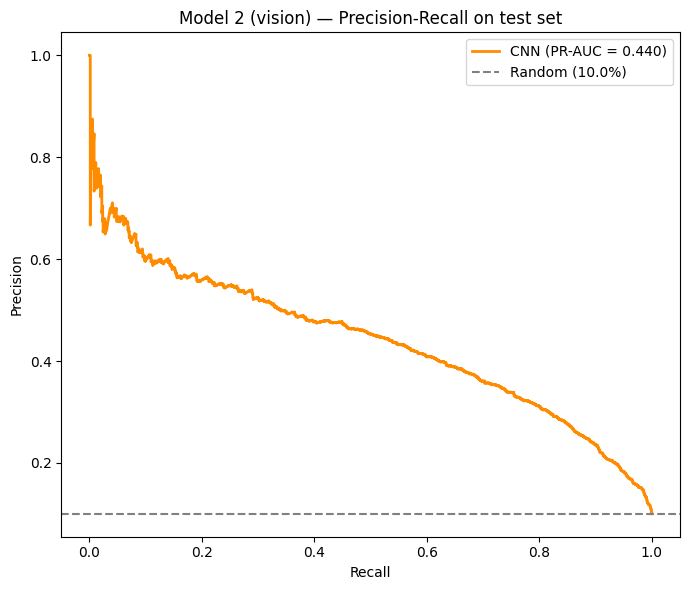

In [ ]:
import gc
import src.models.cnn_evals as cnn_evals
importlib.reload(cnn_evals)

# Build the test dataset with the same channels and train norm stats
patches = gd._load_all_patches()
test_vis = gd.GoesPatchDataset("test", channels=gd.ALL_BANDS,
                               norm_stats=train_vis.norm_stats, patches=patches)
del patches; gc.collect()
print(f"Test patches: {len(test_vis):,}")

# Evaluate the IR+visible model on the untouched test set
results = cnn_evals.evaluate_full(model_vis, test_vis)

## **Model 3 - Multimodal (Late Fusion + Feature-Level Fusion)**

In [ ]:
import os

DRIVE = "/content/drive/MyDrive/smart-patio-shield"

print("1. Is 'models' a symlink in the repo?")
print("   exists:", os.path.exists("models"), "| islink:", os.path.islink("models"))
if os.path.islink("models"):
    print("   points to:", os.readlink("models"))

print("\n2. What's actually in the Drive models folder?")
drive_models = f"{DRIVE}/models"
print("   Drive models exists:", os.path.exists(drive_models))
if os.path.exists(drive_models):
    print("   contents:", os.listdir(drive_models))

print("\n3. What does the repo 'models' resolve to?")
if os.path.exists("models"):
    print("   contents:", os.listdir("models"))

print("\n4. Is the tabular features file linked?")
print("   patio_features.parquet:", os.path.exists("data/processed/patio_features.parquet"))

1. Is 'models' a symlink in the repo?
   exists: True | islink: True
   points to: /content/drive/MyDrive/smart-patio-shield/models

2. What's actually in the Drive models folder?
   Drive models exists: True
   contents: ['cnn_resnet18_ir_only.pt', 'cnn_resnet18_ir_only.manifest.json', 'cnn_resnet18_ir_visible.pt', 'cnn_resnet18_ir_visible.manifest.json', 'logistic_regression.joblib', 'xgboost_baseline.json', 'baseline_training.manifest.json', 'logistic_regression_scaler.joblib']

3. What does the repo 'models' resolve to?
   contents: ['cnn_resnet18_ir_only.pt', 'cnn_resnet18_ir_only.manifest.json', 'cnn_resnet18_ir_visible.pt', 'cnn_resnet18_ir_visible.manifest.json', 'logistic_regression.joblib', 'xgboost_baseline.json', 'baseline_training.manifest.json', 'logistic_regression_scaler.joblib']

4. Is the tabular features file linked?
   patio_features.parquet: True


In [ ]:
import os, shutil

DRIVE = "/content/drive/MyDrive/smart-patio-shield"

# The repo 'models/' holds only the committed manifest; the real artifacts are on Drive.
# Replace the folder with a symlink so all eight Drive files are visible
if os.path.exists("models") and not os.path.islink("models"):
    shutil.rmtree("models")
os.symlink(f"{DRIVE}/models", "models")

print("islink now:", os.path.islink("models"))
print("contents:", os.listdir("models"))

FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/smart-patio-shield/models' -> 'models'

In [ ]:
import importlib, gc, torch
import src.models.goes_dataset as gd
import src.models.cnn as cnn
import src.models.fusion as fus
for m in (gd, cnn, fus): importlib.reload(m)

DRIVE = "/content/drive/MyDrive/smart-patio-shield"

# link tabular features + models into expected paths
import os
for src_p, dst_p in [(f"{DRIVE}/data/patio_features.parquet", "data/processed/patio_features.parquet"),
                     (f"{DRIVE}/models", "models")]:
    if not os.path.exists(dst_p): os.symlink(src_p, dst_p)

# --- tabular branch (CPU, fast) ---
tab = fus.tabular_branch("models/xgboost_baseline.json",
                         "models/baseline_training.manifest.json")
print("tabular val/test rows:", len(tab['val'][0]), len(tab['test'][0]))

# --- vision branch: rebuild val/test datasets (train stats needed) ---
patches = gd._load_all_patches()
train_ds = gd.GoesPatchDataset("train", channels=gd.ALL_BANDS, patches=patches)
NORM = train_ds.norm_stats
del train_ds; gc.collect()
val_ds  = gd.GoesPatchDataset("val",  channels=gd.ALL_BANDS, norm_stats=NORM, patches=patches)
test_ds = gd.GoesPatchDataset("test", channels=gd.ALL_BANDS, norm_stats=NORM, patches=patches)
del patches; gc.collect()

model = cnn.build_model(3)
model.load_state_dict(torch.load(f"{DRIVE}/models/cnn_resnet18_ir_visible.pt"))
img_val,  E_val  = fus.vision_branch(model, val_ds)
img_test, E_test = fus.vision_branch(model, test_ds)
print("vision val/test rows:", len(img_val), len(img_test))

tabular val/test rows: 13154 13156
vision val/test rows: 13154 13108


In [ ]:
val  = fus.align(tab['val'][0],  tab['val'][1],  img_val,  E_val)
test = fus.align(tab['test'][0], tab['test'][1], img_test, E_test)
print(f"aligned val {len(val['y']):,} | test {len(test['y']):,} "
      f"| test positive rate {test['y'].mean():.3f}\n")

print("=== TEST SET — common intersection ===")
fus.report("Model 1 (tabular)",        test["y"], test["p_tab"])
fus.report("Model 2 (vision)",         test["y"], test["p_img"])
p_late, _ = fus.late_fusion(val, test)
fus.report("Model 3a (late fusion)",   test["y"], p_late)
p_feat, _ = fus.feature_fusion(val, test)
fus.report("Model 3b (feature fusion)", test["y"], p_feat)

aligned val 13,154 | test 13,108 | test positive rate 0.100

=== TEST SET — common intersection ===
Model 1 (tabular)                  PR-AUC 0.7557   recall 0.841  precision 0.538
Model 2 (vision)                   PR-AUC 0.4397   recall 0.847  precision 0.279
Model 3a (late fusion)             PR-AUC 0.7342   recall 0.891  precision 0.482
Model 3b (feature fusion)          PR-AUC 0.6663   recall 0.827  precision 0.448


{'name': 'Model 3b (feature fusion)',
 'pr_auc': 0.6662899290584112,
 'confusion_matrix': [[10453, 1340], [227, 1088]]}

Late Fusion Calibration

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
import numpy as np

def isotonic_calibrate(p_val, y_val, p_test):
    """
    Fit an isotonic mapping on validation, apply to test.
    """
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_val, y_val)
    return iso.transform(p_val), iso.transform(p_test)

# --- calibrate each base model's probabilities (fit on val, apply to test) ---
tab_val_c, tab_test_c = isotonic_calibrate(val["p_tab"], val["y"], test["p_tab"])
img_val_c, img_test_c = isotonic_calibrate(val["p_img"], val["y"], test["p_img"])

# --- late fusion on the CALIBRATED probabilities ---
Zv = np.column_stack([tab_val_c,  img_val_c])
Zt = np.column_stack([tab_test_c, img_test_c])
meta = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
meta.fit(Zv, val["y"])
p_late_cal = meta.predict_proba(Zt)[:, 1]

print("=== TEST SET — calibrated late fusion vs baselines ===")
fus.report("Model 1 (tabular)",              test["y"], test["p_tab"])
fus.report("Model 2 (vision)",               test["y"], test["p_img"])
fus.report("Model 3a late fusion (raw)",     test["y"], p_late)         # from Cell B
fus.report("Model 3a late fusion (calibrated)", test["y"], p_late_cal)

# --- also report calibrated single models, for context ---
from sklearn.metrics import average_precision_score
print(f"\nCalibrated Model 1 alone: PR-AUC {average_precision_score(test['y'], tab_test_c):.4f}")
print(f"Calibrated Model 2 alone: PR-AUC {average_precision_score(test['y'], img_test_c):.4f}")

=== TEST SET — calibrated late fusion vs baselines ===
Model 1 (tabular)                  PR-AUC 0.7557   recall 0.841  precision 0.538
Model 2 (vision)                   PR-AUC 0.4397   recall 0.847  precision 0.279
Model 3a late fusion (raw)         PR-AUC 0.7342   recall 0.891  precision 0.482
Model 3a late fusion (calibrated)  PR-AUC 0.7406   recall 0.856  precision 0.527

Calibrated Model 1 alone: PR-AUC 0.7276
Calibrated Model 2 alone: PR-AUC 0.4235


Feature Fusion Calibration

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
import numpy as np

# Refit feature fusion, but capture its VALIDATION predictions too (needed to calibrate)
Fv = np.hstack([val["E_img"],  val["X_tab"]]).astype("float32")
Ft = np.hstack([test["E_img"], test["X_tab"]]).astype("float32")
scaler = StandardScaler().fit(Fv)
head = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
head.fit(scaler.transform(Fv), val["y"])

p_feat_val  = head.predict_proba(scaler.transform(Fv))[:, 1]   # in-sample val preds
p_feat_test = head.predict_proba(scaler.transform(Ft))[:, 1]

# Calibrate on validation, apply to test (leakage-safe: test never seen)
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_feat_val, val["y"])
p_feat_test_cal = iso.transform(p_feat_test)

print("=== TEST SET — feature fusion, raw vs calibrated ===")
fus.report("Model 3b feature fusion (raw)",        test["y"], p_feat)
fus.report("Model 3b feature fusion (calibrated)", test["y"], p_feat_test_cal)
print(f"\n(For reference — Model 1: 0.7557, calibrated late fusion: 0.7406)")

=== TEST SET — feature fusion, raw vs calibrated ===
Model 3b feature fusion (raw)      PR-AUC 0.6663   recall 0.827  precision 0.448
Model 3b feature fusion (calibrated) PR-AUC 0.6429   recall 0.573  precision 0.670

(For reference — Model 1: 0.7557, calibrated late fusion: 0.7406)


In [ ]:
import json, os
from datetime import datetime, timezone
from sklearn.metrics import average_precision_score, confusion_matrix

DRIVE = "/content/drive/MyDrive/smart-patio-shield"

def metrics_block(y, p, threshold=0.5):
    ap = average_precision_score(y, p)
    tn, fp, fn, tp = confusion_matrix(y, (p >= threshold).astype(int)).ravel()
    return {
        "pr_auc": round(float(ap), 4),
        "recall": round(tp / (tp + fn), 4),
        "precision": round(tp / (tp + fp), 4),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }

fusion_results = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation": "held-out test set, common intersection (both modalities present)",
    "n_test_hours": int(len(test["y"])),
    "test_positive_rate": round(float(test["y"].mean()), 4),
    "note": ("Fusion did not beat the tabular baseline. Vision's convective signal "
             "is largely redundant with reanalysis cloud/precip features. Result robust "
             "to probability calibration. Reported on the modality intersection so all "
             "models are compared on identical hours."),
    "models": {
        "model1_tabular":            metrics_block(test["y"], test["p_tab"]),
        "model2_vision_ir_visible":  metrics_block(test["y"], test["p_img"]),
        "model3a_late_fusion_raw":        metrics_block(test["y"], p_late),
        "model3a_late_fusion_calibrated": metrics_block(test["y"], p_late_cal),
        "model3b_feature_fusion_raw":        metrics_block(test["y"], p_feat),
        "model3b_feature_fusion_calibrated": metrics_block(test["y"], p_feat_test_cal),
    },
}

# Save to Drive and print
out_path = f"{DRIVE}/models/model3_fusion_results.json"
with open(out_path, "w") as f:
    json.dump(fusion_results, f, indent=2)
print("Saved:", out_path)
print(json.dumps(fusion_results["models"], indent=2))

Saved: /content/drive/MyDrive/smart-patio-shield/models/model3_fusion_results.json
{
  "model1_tabular": {
    "pr_auc": 0.7557,
    "recall": 0.8411,
    "precision": 0.5379,
    "confusion_matrix": {
      "tn": 10843,
      "fp": 950,
      "fn": 209,
      "tp": 1106
    }
  },
  "model2_vision_ir_visible": {
    "pr_auc": 0.4397,
    "recall": 0.8471,
    "precision": 0.2788,
    "confusion_matrix": {
      "tn": 8911,
      "fp": 2882,
      "fn": 201,
      "tp": 1114
    }
  },
  "model3a_late_fusion_raw": {
    "pr_auc": 0.7342,
    "recall": 0.8913,
    "precision": 0.4823,
    "confusion_matrix": {
      "tn": 10535,
      "fp": 1258,
      "fn": 143,
      "tp": 1172
    }
  },
  "model3a_late_fusion_calibrated": {
    "pr_auc": 0.7406,
    "recall": 0.8555,
    "precision": 0.5274,
    "confusion_matrix": {
      "tn": 10785,
      "fp": 1008,
      "fn": 190,
      "tp": 1125
    }
  },
  "model3b_feature_fusion_raw": {
    "pr_auc": 0.6663,
    "recall": 0.8274,
    "pre

## CNN inference over training hours

In [2]:
import importlib, gc, torch
import src.models.goes_dataset as gd
import src.models.cnn as cnn
import src.models.fusion as fus
for m in (gd, cnn, fus): importlib.reload(m)

DRIVE = "/content/drive/MyDrive/smart-patio-shield"

patches = gd._load_all_patches()
train_ds = gd.GoesPatchDataset("train", channels=gd.ALL_BANDS, patches=patches)
NORM = train_ds.norm_stats
val_ds  = gd.GoesPatchDataset("val",  channels=gd.ALL_BANDS, norm_stats=NORM, patches=patches)
test_ds = gd.GoesPatchDataset("test", channels=gd.ALL_BANDS, norm_stats=NORM, patches=patches)
del patches; gc.collect()

model = cnn.build_model(3)
model.load_state_dict(torch.load(f"{DRIVE}/models/cnn_resnet18_ir_visible.pt"))

img_train, E_train = fus.vision_branch(model, train_ds)
img_val,   E_val   = fus.vision_branch(model, val_ds)
img_test,  E_test  = fus.vision_branch(model, test_ds)
print("vision rows — train/val/test:", len(img_train), len(img_val), len(img_test))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


vision rows — train/val/test: 61386 13154 13108


In [5]:
if not os.path.exists("data/processed/patio_features.parquet"):
    os.symlink(f"{DRIVE}/data/patio_features.parquet", "data/processed/patio_features.parquet")
print(os.path.exists("data/processed/patio_features.parquet"))

True


In [6]:
oof_tab, oof_X = fus.oof_tabular_predictions(
    "models/xgboost_baseline.json", "models/baseline_training.manifest.json")
print(f"OOF rows: {len(oof_tab):,}")

train_al = fus.align(oof_tab, oof_X, img_train, E_train)
test_al  = fus.align(tab['test'][0], tab['test'][1], img_test, E_test)
print(f"aligned — stack-fit {len(train_al['y']):,} | test {len(test_al['y']):,}")

p_oof_late, meta_oof = fus.late_fusion(train_al, test_al)
print("\n=== TEST — out-of-fold stacking ===")
fus.report("Model 1 (tabular)",                  test_al["y"], test_al["p_tab"])
fus.report("Model 3a late fusion (val-fitted)",  test_al["y"], p_late)
fus.report("Model 3a late fusion (OOF-fitted)",  test_al["y"], p_oof_late)
print("meta-learner coefficients [tab, img]:", meta_oof.coef_)

  fold 1: trained on 10,229 → predicted 10,229
  fold 2: trained on 20,458 → predicted 10,229
  fold 3: trained on 30,687 → predicted 10,229
  fold 4: trained on 40,916 → predicted 10,229
  fold 5: trained on 51,145 → predicted 10,229
OOF rows: 51,145


NameError: name 'tab' is not defined

In [8]:
import os
DRIVE = "/content/drive/MyDrive/smart-patio-shield"
for root, dirs, files in os.walk(DRIVE):
    depth = root.replace(DRIVE, "").count("/")
    if depth > 2: continue
    print(root.replace(DRIVE, "DRIVE") + "/")
    for f in sorted(files):
        print("   ", f)

DRIVE/
DRIVE/data/
    image_labels.parquet
    patio_features.parquet
DRIVE/data/goes/
    goes_2021-05-01.npz
    goes_2021-05-02.npz
    goes_2021-05-03.npz
    goes_2021-05-04.npz
    goes_2021-05-05.npz
    goes_2021-05-06.npz
    goes_2021-05-07.npz
    goes_2021-05-08.npz
    goes_2021-05-09.npz
    goes_2021-05-10.npz
    goes_2021-05-11.npz
    goes_2021-05-12.npz
    goes_2021-05-13.npz
    goes_2021-05-14.npz
    goes_2021-05-15.npz
    goes_2021-05-16.npz
    goes_2021-05-17.npz
    goes_2021-05-18.npz
    goes_2021-05-19.npz
    goes_2021-05-20.npz
    goes_2021-05-21.npz
    goes_2021-05-22.npz
    goes_2021-05-23.npz
    goes_2021-05-24.npz
    goes_2021-05-25.npz
    goes_2021-05-26.npz
    goes_2021-05-27.npz
    goes_2021-05-28.npz
    goes_2021-05-29.npz
    goes_2021-05-30.npz
    goes_2021-05-31.npz
    goes_2021-06-01.npz
    goes_2021-06-02.npz
    goes_2021-06-03.npz
    goes_2021-06-04.npz
    goes_2021-06-05.npz
    goes_2021-06-06.npz
    goes_2021-06-07.npz
